**Task 4. Nature Reserve – European Bison**

Ninety bison live in the nature reserve. From December 1, 2012, to February 28, 2013, the forest district fed these animals hay or acorns.
On December 1, 2012, in the morning (before the bison's meal), there were 100 tons of hay and 5 tons of acorns in the warehouse.
As long as the hay supply in the warehouse reached at least 50 tons, the bison were fed exclusively hay each morning (40 kg of hay for each bison). Otherwise, until the hay supply was replenished to at least 50 tons, the bison were fed exclusively acorns (20 kg of acorns for each bison). After replenishing the hay supply, they returned to feeding exclusively hay.

Every Friday evening (after the bison's meal), 15 tons of hay were delivered to the warehouse, while every Tuesday (also in the evening, after the bison's meal), 4 tons of acorns were delivered.

Using the available IT tools, complete the following instructions.

a) Provide the number of hay deliveries and the number of acorn deliveries during the period from December 1, 2012, to February 28, 2013.

b) On which feeding day will the bison first receive only acorns?

c) How many times during the entire period, from December 1, 2012, to February 28, 2013, were the bison fed only hay, and how many times only acorns?

d) Compile the morning food supply levels for the bison (tons of hay and tons of acorns) on December 31, 2012, January 31, 2013, and February 28, 2013.

Create a column chart for the above table. Remember to provide a clear description of the chart.

e) Provide the maximum number of bison that can be added to the herd to still be able to feed it within the given time period, using the method described in the problem.

In [237]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [238]:
number_of_bisons = 90
warehouse = pd.DataFrame()
warehouse["date"] = pd.date_range("2012-12-01", "2013-3-1")
warehouse["hay"] = 0
warehouse["acorns"] = 0
warehouse.loc[0, "hay"] = 100000
warehouse.loc[0, "acorns"] = 5000

In [239]:
number_of_hay_deliveries = 0
number_of_acorns_deliveries = 0
number_of_hay_feedings = 0
number_of_acorns_feedings = 0
only_corns = None
warehouse["day_name"] = warehouse["date"].dt.day_name()
amount_of_hay = []
amount_of_corn = []
for i in range(len(warehouse) - 1):
  if warehouse.loc[i, "date"] in pd.to_datetime(["2012-12-31", "2013-01-31", "2013-02-28"]):
     amount_of_hay.append(warehouse.loc[i, "hay"])
     amount_of_corn.append(warehouse.loc[i, "acorns"])
  if warehouse.loc[i, "hay"] >= 50000:
    warehouse.loc[i, "hay"] = warehouse.loc[i, "hay"] - 40 * number_of_bisons
    number_of_hay_feedings += 1
  else:
    warehouse.loc[i, "acorns"] = warehouse.loc[i, "acorns"] - 20 * number_of_bisons
    number_of_acorns_feedings += 1
    if only_corns is None:
      only_corns = i
  if warehouse.loc[i, "date"].dayofweek == 4:
    number_of_hay_deliveries = number_of_hay_deliveries + 1
    warehouse.loc[i, "hay"] = warehouse.loc[i, "hay"] + 15000
  if warehouse.loc[i, "date"].dayofweek == 1:
    number_of_acorns_deliveries += 1
    warehouse.loc[i, "acorns"] = warehouse.loc[i, "acorns"] + 4000
  warehouse.loc[i + 1, "hay"] = warehouse.loc[i, "hay"]
  warehouse.loc[i + 1, "acorns"] = warehouse.loc[i, "acorns"]


In [240]:
print("Point a)")
print(f"Number of hay deliveries from December 1, 2012 to February 28, 2013: {number_of_hay_deliveries}")
print(f"Number of acorns deliveries from December 1, 2012 to February 28, 2013: {number_of_acorns_deliveries}")

Point a)
Number of hay deliveries from December 1, 2012 to February 28, 2013: 12
Number of acorns deliveries from December 1, 2012 to February 28, 2013: 13


In [241]:
print("Point b")
print(f"For the first time, the bison will only receive acorns on {warehouse.loc[only_corns, "date"]}")

Point b
For the first time, the bison will only receive acorns on 2012-12-28 00:00:00


In [242]:
print("Point c")
print(f"Number of hay feedings: {number_of_hay_feedings}")
print(f"Number of acorns feedings: {number_of_acorns_feedings}")

Point c
Number of hay feedings: 64
Number of acorns feedings: 26


In [243]:
print("Point d")
print("    Date   |  Hay  | Corn")
print("------------------------")
i = 0
for d in ["2012-12-31", "2013-01-31", "2013-02-28"]:
  print(f"{d} | {amount_of_hay[i]/1000}  | {amount_of_corn[i]/1000}")
  i += 1


Point d
    Date   |  Hay  | Corn
------------------------
2012-12-31 | 55.6  | 19.2
2013-01-31 | 47.2  | 17.6
2013-02-28 | 49.6  | 12.0


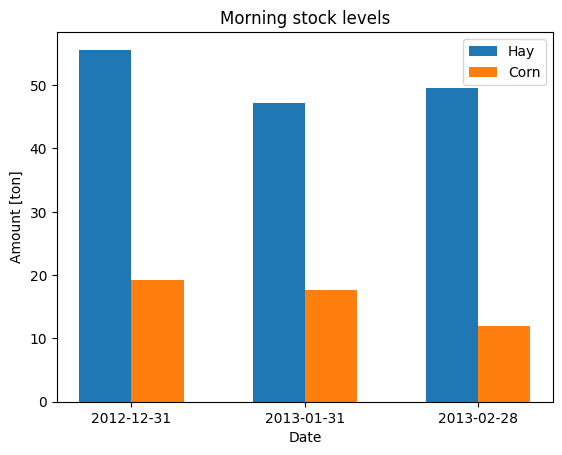

In [244]:
dates = ["2012-12-31", "2013-01-31", "2013-02-28"]
amount_of_corn = np.array(amount_of_corn)  / 1000
amount_of_hay = np.array(amount_of_hay) / 1000
x = np.arange(len(dates))
width = 0.3

fig, ax = plt.subplots()
ax.bar(x - width/2, amount_of_hay, width, label="Hay")
ax.bar(x + width/2, amount_of_corn, width, label="Corn")


ax.set_xticks(x)
ax.set_xticklabels(dates)
ax.set_title("Morning stock levels")
ax.set_xlabel("Date")
ax.set_ylabel("Amount [ton]")
ax.legend()

In [245]:
start_number_of_bisons = number_of_bisons
while True:
  number_of_bisons += 1
  warehouse = pd.DataFrame()
  warehouse["date"] = pd.date_range("2012-12-01", "2013-3-1")
  warehouse["hay"] = 0
  warehouse["acorns"] = 0
  warehouse.loc[0, "hay"] = 100000
  warehouse.loc[0, "acorns"] = 5000
  warehouse["day_name"] = warehouse["date"].dt.day_name()
  starved = False
  for i in range(len(warehouse) - 1):
    if warehouse.loc[i, "hay"] >= 50000:
      warehouse.loc[i, "hay"] = warehouse.loc[i, "hay"] - 40 * number_of_bisons
      if warehouse.loc[i, "hay"] <= 0:
        starved = True
        break
    else:
      warehouse.loc[i, "acorns"] = warehouse.loc[i, "acorns"] - 20 * number_of_bisons
      if warehouse.loc[i, "acorns"] <= 0:
        starved = True
        break
    if warehouse.loc[i, "date"].dayofweek == 4:
      warehouse.loc[i, "hay"] = warehouse.loc[i, "hay"] + 15000
    if warehouse.loc[i, "date"].dayofweek == 1:
      warehouse.loc[i, "acorns"] = warehouse.loc[i, "acorns"] + 4000
    warehouse.loc[i + 1, "hay"] = warehouse.loc[i, "hay"]
    warehouse.loc[i + 1, "acorns"] = warehouse.loc[i, "acorns"]
  if starved:
    break
print("Point e")
print(f"The largest number of bison that can be added to the herd to still be able to feed it within the given time frame is: {number_of_bisons - start_number_of_bisons - 1}")



Point e
The largest number of bison that can be added to the herd to still be able to feed it within the given time frame is: 5
